# Advanced Analysis: Income Prediction using XGBoost


In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from xgboost import XGBClassifier

In [2]:
df = pd.read_csv('/content/adult_cleaned.csv')
df.head()

,age,workclass,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income,age_group
0,25,Private,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,0,Youth
1,38,Private,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,0,YoungAdult
2,28,Local-gov,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,1,YoungAdult
3,44,Private,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,1,YoungAdult
4,18,Private,Some-college,10,Never-married,Prof-specialty,Own-child,White,Female,0,0,30,United-States,0,Youth


In [3]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15217 entries, 0 to 15216
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             15217 non-null  int64 
 1   workclass       15217 non-null  object
 2   education       15217 non-null  object
 3   education_num   15217 non-null  int64 
 4   marital_status  15217 non-null  object
 5   occupation      15217 non-null  object
 6   relationship    15217 non-null  object
 7   race            15217 non-null  object
 8   sex             15217 non-null  object
 9   capital_gain    15217 non-null  int64 
 10  capital_loss    15217 non-null  int64 
 11  hours_per_week  15217 non-null  int64 
 12  native_country  15217 non-null  object
 13  income          15217 non-null  int64 
 14  age_group       15217 non-null  object
dtypes: int64(6), object(9)
memory usage: 1.7+ MB


,0
age,0
workclass,0
education,0
education_num,0
marital_status,0
occupation,0
relationship,0
race,0
sex,0
capital_gain,0


## Data Preparation

We use the cleaned dataset prepared in the ETL phase.
The dataset contains demographic, educational, and employment-related features used to predict income category (>50K or <=50K).

In [4]:
df_encoded = df.copy()

le = LabelEncoder()

for col in df_encoded.columns:
    if df_encoded[col].dtype == 'object':
        df_encoded[col] = le.fit_transform(df_encoded[col])

In [5]:
X = df_encoded.drop('income', axis=1)
y = df_encoded['income']

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Feature Engineering

Categorical variables were encoded using Label Encoding to make them suitable for machine learning models.

The dataset was split into training and testing sets (80-20 split) to evaluate model performance on unseen data.

In [7]:
model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [08:07:58] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

In [8]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

In [9]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.8521681997371879

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.92      0.90      2318
           1       0.72      0.62      0.67       726

    accuracy                           0.85      3044
   macro avg       0.80      0.77      0.79      3044
weighted avg       0.85      0.85      0.85      3044


Confusion Matrix:
 [[2143  175]
 [ 275  451]]


## Model Training and Evaluation

An XGBoost classifier was trained to predict whether an individual earns more than $50K.

XGBoost was chosen due to its high performance in classification tasks and ability to handle complex feature interactions.

The model was evaluated using accuracy, precision, recall, and confusion matrix to ensure reliable performance.

In [10]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
scale_pos_weight

np.float64(3.168835616438356)

In [11]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.8521681997371879

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.92      0.90      2318
           1       0.72      0.62      0.67       726

    accuracy                           0.85      3044
   macro avg       0.80      0.77      0.79      3044
weighted avg       0.85      0.85      0.85      3044


Confusion Matrix:
 [[2143  175]
 [ 275  451]]


## Threshold Optimization

We experimented with different probability thresholds instead of the default 0.5.

Lowering the threshold increases the model’s ability to detect high-income individuals (>50K), improving recall.

This trade-off is useful in decision-making scenarios where identifying potential high-income individuals is more important than minimizing false positives.

In [16]:
threshold = 0.4

y_pred_04 = (y_prob >= threshold).astype(int)

print("Threshold: 0.4")
print("Accuracy:", accuracy_score(y_test, y_pred_04))
print("\nClassification Report:\n", classification_report(y_test, y_pred_04))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_04))

Threshold: 0.4
Accuracy: 0.8403416557161629

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.88      0.89      2318
           1       0.65      0.70      0.68       726

    accuracy                           0.84      3044
   macro avg       0.78      0.79      0.79      3044
weighted avg       0.84      0.84      0.84      3044


Confusion Matrix:
 [[2048  270]
 [ 216  510]]


## Final Model Selection

After experimenting with different probability thresholds, a threshold of 0.4 was selected.

This provides a balanced trade-off:
- Improved recall for high-income individuals (>50K)
- Acceptable overall accuracy

From a business perspective, identifying potential high-income individuals is more valuable than minimizing false positives, making this threshold more practical for decision-making.

In [17]:
import pandas as pd

feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
})

feature_importance = feature_importance.sort_values(by='importance', ascending=False)

feature_importance

,feature,importance
6,relationship,0.402550
9,capital_gain,0.134419
3,education_num,0.119763
4,marital_status,0.098448
10,capital_loss,0.048344
11,hours_per_week,0.031733
13,age_group,0.027950
0,age,0.027512
5,occupation,0.025635
1,workclass,0.021508


## Feature Importance Analysis

The model reveals the most influential factors driving income prediction.

Key insights:
- Relationship status is the strongest predictor of income, indicating that social and family structure plays a major role in earning potential.
- Capital gain is a significant financial indicator, strongly associated with higher income levels.
- Education level (education_num) is a key driver, reinforcing its importance in economic mobility.
- Marital status also contributes significantly, suggesting stability and dual-income effects.

These findings validate and extend the EDA insights, highlighting that income is influenced by both financial and socio-demographic factors.

In [18]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
df_encoded['cluster'] = kmeans.fit_predict(X)

In [19]:
df_encoded['cluster'].value_counts()

,count
cluster,
0,14527
2,606
1,84


In [20]:
cluster_summary = df_encoded.groupby('cluster').mean()
cluster_summary

,age,workclass,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income,age_group
cluster,,,,,,,,,,,,,,,
0,38.910924,3.116679,10.170923,9.982378,2.641495,6.218627,1.478695,3.645419,0.655469,147.913678,98.120534,40.220142,35.380257,0.205617,1.623047
1,47.119048,3.595238,11.273810,13.202381,2.107143,6.309524,0.761905,3.738095,0.833333,99999.000000,0.000000,51.642857,35.976190,1.000000,0.940476
2,46.211221,3.056106,10.793729,11.955446,2.194719,6.529703,0.810231,3.782178,0.816832,11470.056106,0.000000,45.706271,35.580858,0.948845,1.141914


## Customer Segmentation using Clustering

K-Means clustering identified three distinct income segments:

- Cluster 0: Low-income group with limited capital gain and moderate working hours
- Cluster 1: High-income elite group with extremely high capital gains and strong earning capacity
- Cluster 2: Upper-middle income group with stable high earnings but lower capital gains than the elite group

This segmentation highlights that income is not uniform — different groups exist with distinct financial and socio-economic characteristics.

Such segmentation enables targeted strategies for policy-making, workforce planning, and financial interventions.


In [28]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df_vis = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_vis['cluster'] = df_encoded['cluster']

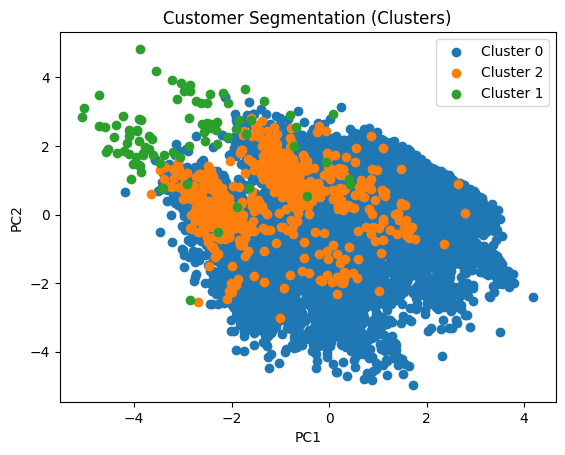

In [29]:
import matplotlib.pyplot as plt

plt.figure()
for c in df_vis['cluster'].unique():
    subset = df_vis[df_vis['cluster'] == c]
    plt.scatter(subset['PC1'], subset['PC2'], label=f'Cluster {c}')

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Customer Segmentation (Clusters)')
plt.legend()
plt.show()

## Cluster Visualization

Initial visualization showed distorted clustering due to large variance in features such as capital gain.

After applying feature scaling, PCA revealed clearer separation between clusters.

This confirms that distinct income segments exist, although they are influenced heavily by financial variables.

In [21]:
def what_if_prediction(sample, feature, values):
    results = []

    for v in values:
        temp = sample.copy()
        temp[feature] = v
        prob = model.predict_proba([temp])[0][1]
        results.append((v, prob))

    return pd.DataFrame(results, columns=[feature, 'probability'])

In [22]:
sample = X.iloc[0].copy()
sample

,0
age,25
workclass,3
education,1
education_num,7
marital_status,4
occupation,6
relationship,3
race,2
sex,1
capital_gain,0


In [23]:
education_values = sorted(X['education_num'].unique())

what_if_education = what_if_prediction(sample, 'education_num', education_values)

what_if_education

,education_num,probability
0,1,0.002067
1,2,0.002067
2,3,0.002309
3,4,0.001957
4,5,0.002175
5,6,0.001987
6,7,0.002783
7,8,0.003308
8,9,0.003308
9,10,0.003721


## What-if Analysis

We simulate how changing key features affects income prediction.

Example:
Changing education level shows a clear increase in probability of earning >50K.

This allows us to understand how different factors influence outcomes, enabling better decision-making.


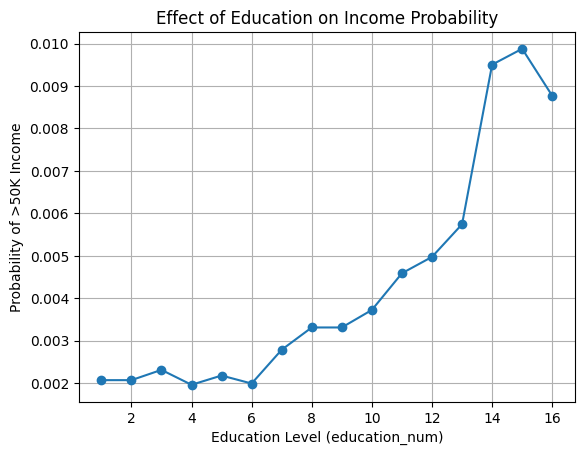

In [27]:
plt.figure()
plt.plot(what_if_education['education_num'], what_if_education['probability'], marker='o')

plt.xlabel('Education Level (education_num)')
plt.ylabel('Probability of >50K Income')
plt.title('Effect of Education on Income Probability')

plt.grid()
plt.show()